In [2]:
import os
os.chdir("../")
print(os.getcwd())

/data/chen/detect


Mean: 0.003663244192162144
Std: 0.08081200960619989
Min: -1.3875673152124712
Max: 1.388232762231765


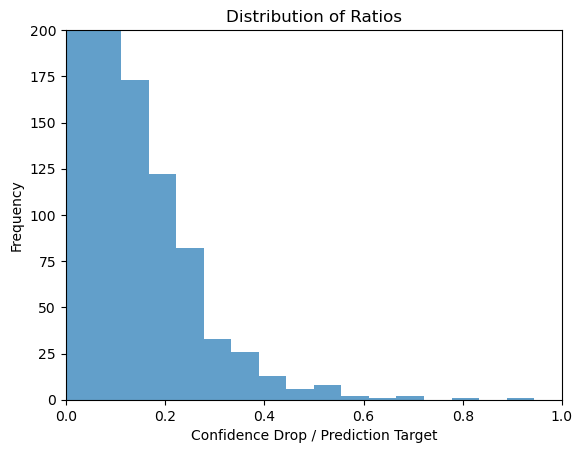

In [12]:
import json 
import glob
import numpy as np

dir_path = "runs_/facial_small_random_confidence_drop_0318_1250"

# Use glob to get all JSON files in subfolders
json_files = glob.glob(os.path.join(dir_path, '**', '*.json'), recursive=True)

import matplotlib.pyplot as plt

ratios = []
for file in json_files:
    with open(file, 'r') as f:
        data = json.load(f)
    # Assuming data contains 'confidence_drop' and 'prediction_target' as lists
    c = data.get('confidence_drop', 0)
    p = data.get('prediction_target', 0)

    if p != 0:
        ratios.append(c / p)

# Statistical analysis
if ratios:
    print("Mean:", np.mean(ratios))
    print("Std:", np.std(ratios))
    print("Min:", np.min(ratios))
    print("Max:", np.max(ratios))
    
    # Plot distribution
    plt.hist(ratios, bins=50, alpha=0.7)
    plt.xlim(0, 1)  # Set x-axis limits to focus on the range of interest
    plt.ylim(0, 200)  # Set y-axis limits to focus on the frequency range
    plt.xlabel('Confidence Drop / Prediction Target')
    plt.ylabel('Frequency')
    plt.title('Distribution of Ratios')
    plt.show()
else:
    print("No valid ratios found.")

Mean: 0.003663244192162144
Std: 0.08081200960619989
Min: -1.3875673152124712
Max: 1.388232762231765


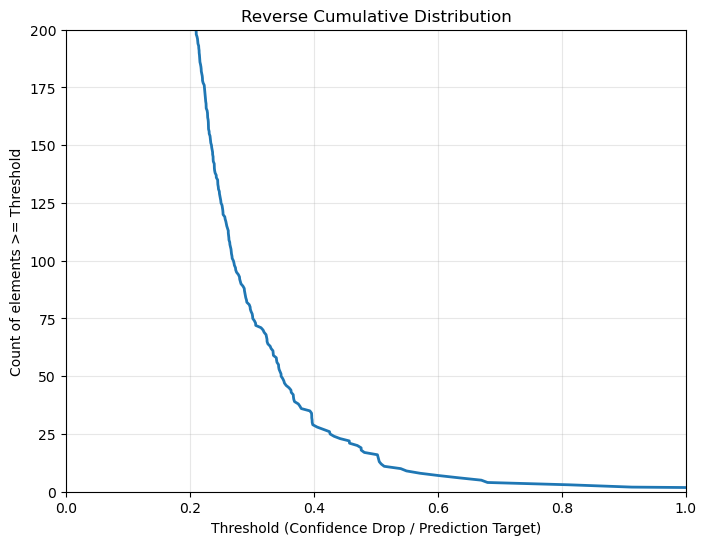

In [15]:
import json 
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

dir_path = "runs_/facial_small_random_confidence_drop_0318_1250"

# Use glob to get all JSON files in subfolders
json_files = glob.glob(os.path.join(dir_path, '**', '*.json'), recursive=True)

ratios = []
for file in json_files:
    with open(file, 'r') as f:
        data = json.load(f)
    # Assuming data contains 'confidence_drop' and 'prediction_target' as lists
    c = data.get('confidence_drop', 0)
    p = data.get('prediction_target', 0)

    if p != 0:
        ratios.append(c / p)

# Statistical analysis
if ratios:
    print("Mean:", np.mean(ratios))
    print("Std:", np.std(ratios))
    print("Min:", np.min(ratios))
    print("Max:", np.max(ratios))
    
    # --- 修改的部分开始 ---
    
    # 1. 将所有比值从小到大排序作为 x 轴（即不同的 threshold）
    sorted_ratios = np.sort(ratios)
    
    # 2. 计算包含比它大的所有数的个数作为 y 轴
    # 数组长度为 N。对于第 0 个 threshold，有 N 个数大于等于它；
    # 第 1 个 threshold 有 N-1 个数大于等于它，以此类推直到 1。
    y_counts = np.arange(len(sorted_ratios), 0, -1)
    
    # 如果你想看的是“比例”而不是“具体个数”，可以把上面这行替换成：
    # y_counts = np.arange(len(sorted_ratios), 0, -1) / len(sorted_ratios)
    
    # 3. 绘制反向累计曲线
    plt.figure(figsize=(8, 6))
    plt.plot(sorted_ratios, y_counts, linestyle='-', marker='', linewidth=2)
    
    plt.xlim(0, 1)  # 根据你的需求可以保留 x 轴限制
    # 由于现在画的是累加值，最大值会是总样本数(len(ratios))，所以将原本的 ylim 注释掉或根据需要修改
    plt.ylim(0, 200) 
    
    plt.xlabel('Threshold (Confidence Drop / Prediction Target)')
    plt.ylabel('Count of elements >= Threshold') # 如果改成了比例，这里改成 'Proportion of elements >= Threshold'
    plt.title('Reverse Cumulative Distribution')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- 修改的部分结束 ---
else:
    print("No valid ratios found.")

有效数据总数 (Ratio > 0): 4023
最佳正阈值 (Positive Sweet Spot): 0.1512
此时保留的正数据比例: 8.40%


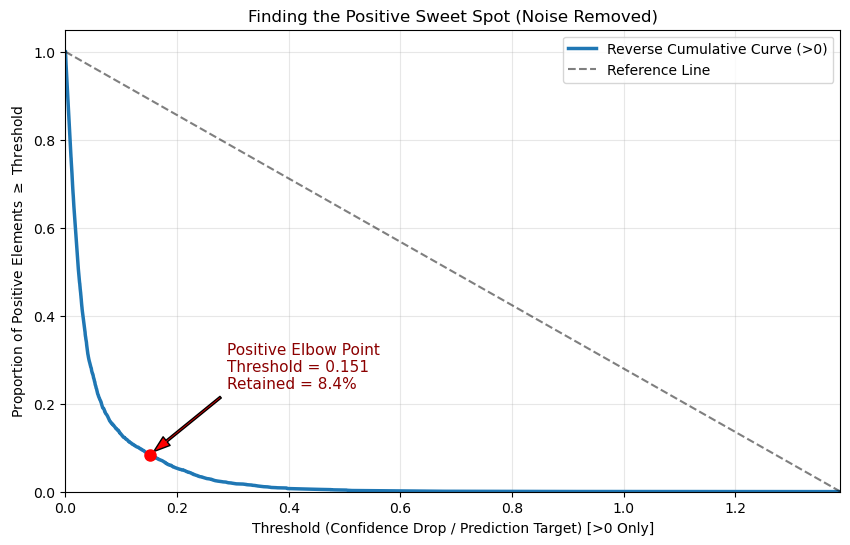

In [20]:
import json 
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

dir_path = "runs_/facial_small_random_confidence_drop_0318_1250"

json_files = glob.glob(os.path.join(dir_path, '**', '*.json'), recursive=True)

ratios = []
for file in json_files:
    with open(file, 'r') as f:
        data = json.load(f)
    c = data.get('confidence_drop', 0)
    p = data.get('prediction_target', 0)

    if p != 0:
        ratios.append(c / p)

# --- 核心修改：过滤掉 <= 0 的噪声数据，只保留正数 ---
positive_ratios = [r for r in ratios if r > 0]

if positive_ratios:
    # 1. 排序并计算比例
    sorted_ratios = np.sort(positive_ratios)
    y_proportions = np.arange(len(sorted_ratios), 0, -1) / len(sorted_ratios)
    
    # --- 计算拐点 (Elbow Point) ---
    # 归一化 X 轴 (基于正数数据的 min 和 max)
    x_min, x_max = sorted_ratios.min(), sorted_ratios.max()
    x_norm = (sorted_ratios - x_min) / (x_max - x_min)
    y_norm = y_proportions
    
    # 取曲线的正数域起点和终点
    p1 = np.array([x_norm[0], y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])
    
    # 计算曲线上每一个点到连线的垂直距离
    distances = []
    for i in range(len(sorted_ratios)):
        p = np.array([x_norm[i], y_norm[i]])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    
    # 距离最大的点即为正数域的拐点
    elbow_index = np.argmax(distances)
    elbow_x = sorted_ratios[elbow_index]
    elbow_y = y_proportions[elbow_index]
    
    print(f"有效数据总数 (Ratio > 0): {len(positive_ratios)}")
    print(f"最佳正阈值 (Positive Sweet Spot): {elbow_x:.4f}")
    print(f"此时保留的正数据比例: {elbow_y * 100:.2f}%")
    
    # --- 绘图 ---
    plt.figure(figsize=(10, 6))
    
    plt.plot(sorted_ratios, y_proportions, linestyle='-', marker='', linewidth=2.5, label='Reverse Cumulative Curve (>0)')
    
    plt.plot([sorted_ratios[0], sorted_ratios[-1]], 
             [y_proportions[0], y_proportions[-1]], 
             'k--', alpha=0.5, label='Reference Line')
    
    plt.plot(elbow_x, elbow_y, 'ro', markersize=8, zorder=5)
    
    plt.annotate(f'Positive Elbow Point\nThreshold = {elbow_x:.3f}\nRetained = {elbow_y*100:.1f}%', 
                 xy=(elbow_x, elbow_y), 
                 xytext=(elbow_x + (x_max-x_min)*0.1, elbow_y + 0.15), # 动态调整文字位置
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=11, color='darkred')

    # 将 X 轴限制从 0 开始，便于观察正数域的分布
    plt.xlim(0, max(1.0, x_max)) 
    plt.ylim(0, 1.05)
    plt.xlabel('Threshold (Confidence Drop / Prediction Target) [>0 Only]')
    plt.ylabel('Proportion of Positive Elements $\geq$ Threshold')
    plt.title('Finding the Positive Sweet Spot (Noise Removed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("No valid positive ratios found.")

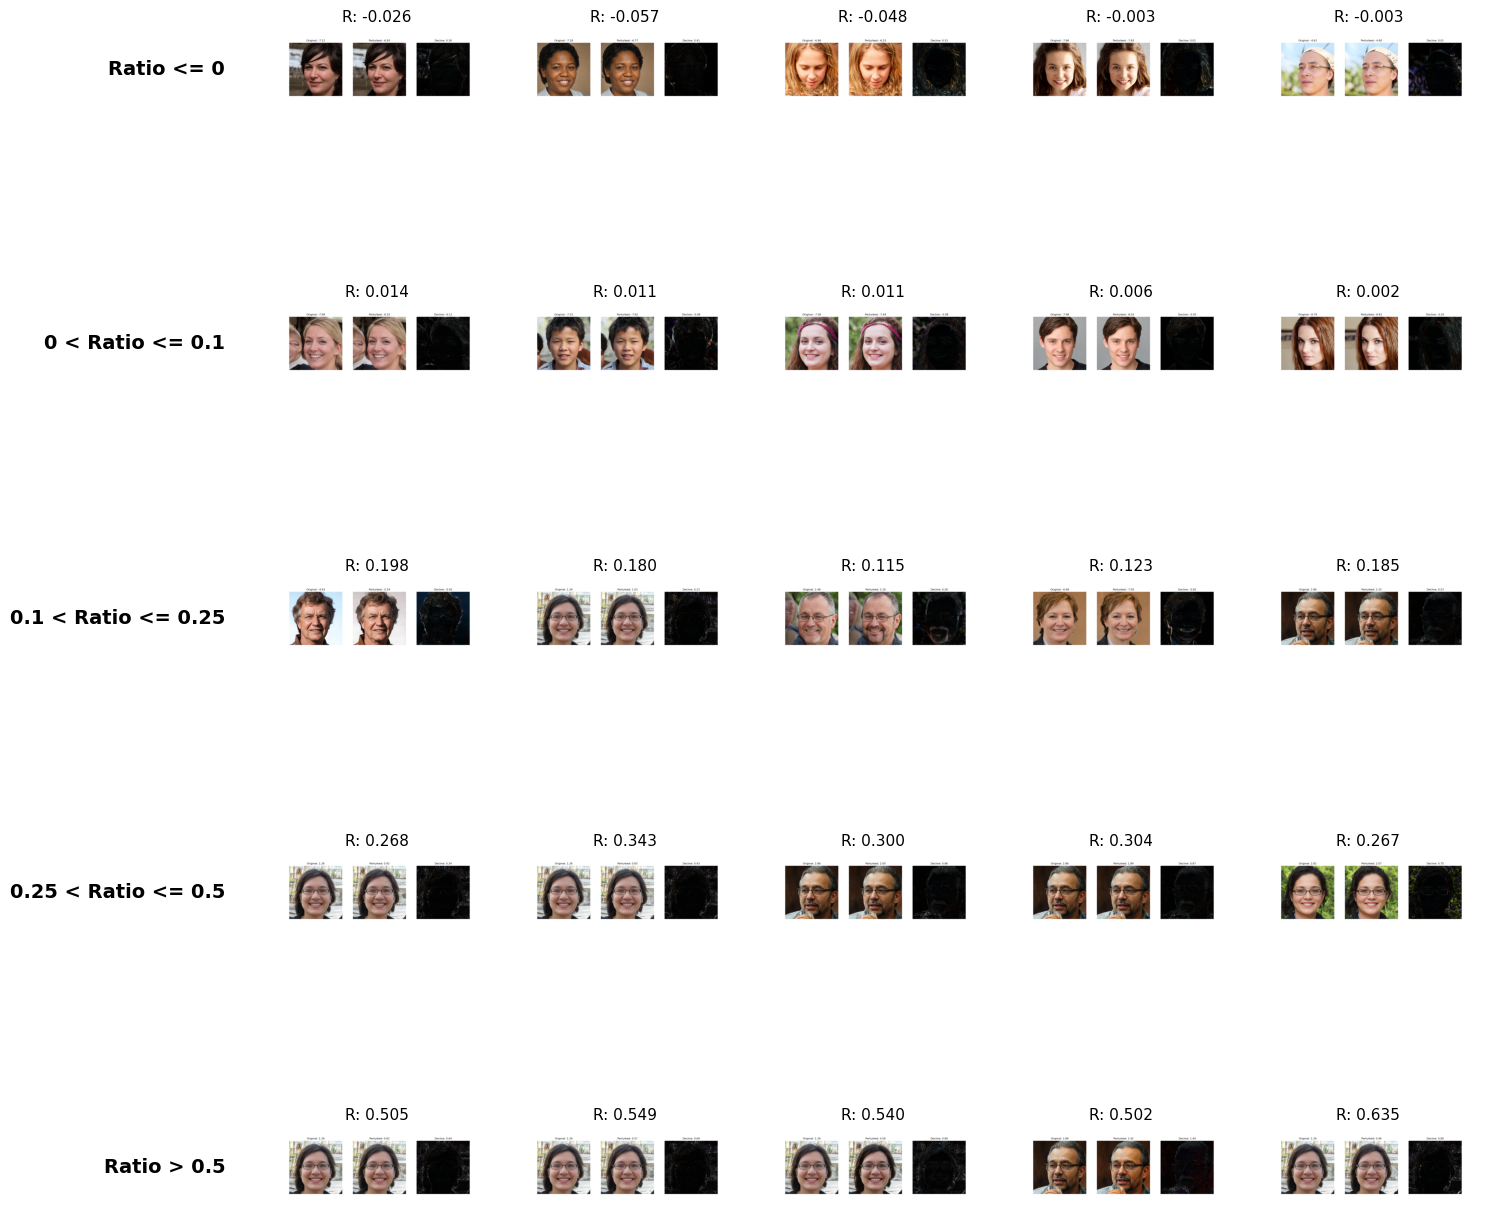

In [ ]:
import json 
import glob
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

dir_path = "runs_/facial_small_random_confidence_drop_0318_1250"
json_files = glob.glob(os.path.join(dir_path, '**', '*.json'), recursive=True)

# 存储解析后的数据：(ratio, img_path)
data_pairs = []

for file in json_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
    c = data.get('confidence_drop', 0)
    p = data.get('prediction_target', 0)
    # 获取图片路径，如果没有这个字段则返回 None
    img_path = data.get('img_path', None)
    img_path = img_path.replace(".png", "_comparison.png") if img_path else None
    if p != 0 and img_path is not None:
        ratio = c / p
        data_pairs.append((ratio, img_path))

# --- 1. 定义 Threshold 区间 (Bins) ---
# 你可以根据之前算出来的 Elbow Point (Sweet Spot) 来修改这里的区间
# 比如如果最佳正阈值是 0.15，你可以设为：<=0, 0~0.15, 0.15~0.3, >0.3
bins = [
    (float('-inf'), 0),    # <= 0 (完全的噪声/负值)
    (0, 0.1),              # 0 ~ 0.1 (低分值区间)
    (0.1, 0.25),           # 0.1 ~ 0.25 (可能包含 Elbow Point 的中等区间)
    (0.25, 0.5),           # 0.25 ~ 0.5 (较高分值区间)
    (0.5, float('inf'))    # > 0.5 (极高分值区间，高度确信的特征)
]

# 将数据按区间分类
interval_samples = {b: [] for b in bins}

for ratio, path in data_pairs:
    for b in bins:
        if b[0] < ratio <= b[1]:
            interval_samples[b].append((ratio, path))
            break

# --- 2. 每个区间随机抽取 5 张图片 ---
num_samples = 5
sampled_data = {}
for b, items in interval_samples.items():
    if len(items) >= num_samples:
        sampled_data[b] = random.sample(items, num_samples)
    else:
        sampled_data[b] = items # 如果该区间不到 5 张，就有几张取几张

# --- 3. 绘图展示 ---
num_bins = len(bins)
# 创建画布，行数为区间数，列数为5
fig, axes = plt.subplots(num_bins, num_samples, figsize=(15, 3 * num_bins))

for i, b in enumerate(bins):
    samples = sampled_data[b]
    
    # 构建当前区间的标签名
    if b[0] == float('-inf'): bin_label = f"Ratio <= {b[1]}"
    elif b[1] == float('inf'): bin_label = f"Ratio > {b[0]}"
    else: bin_label = f"{b[0]} < Ratio <= {b[1]}"

    for j in range(num_samples):
        ax = axes[i][j]
        ax.axis('off') # 隐藏坐标轴
        
        if j < len(samples):
            ratio, img_path = samples[j]
            try:
                # 读取图片并显示
                img = Image.open(img_path)
                ax.imshow(img)
                # 在图片上方显示具体的 Ratio 值
                ax.set_title(f"R: {ratio:.3f}", fontsize=11)
            except Exception as e:
                # 如果因为路径不对找不到图片，显示占位文本
                ax.text(0.5, 0.5, "Image Not Found\nCheck Path", ha='center', va='center', color='red')
                ax.set_title(f"R: {ratio:.3f}", fontsize=11)
        else:
            # 如果该区间图片不够5张，留空
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='gray')

    # 在每一行的最左侧添加区间标签（Y轴标题）
    axes[i][0].text(-0.15, 0.5, bin_label, transform=axes[i][0].transAxes, 
                    fontsize=14, va='center', ha='right', weight='bold', rotation=0)

plt.tight_layout()
plt.show()

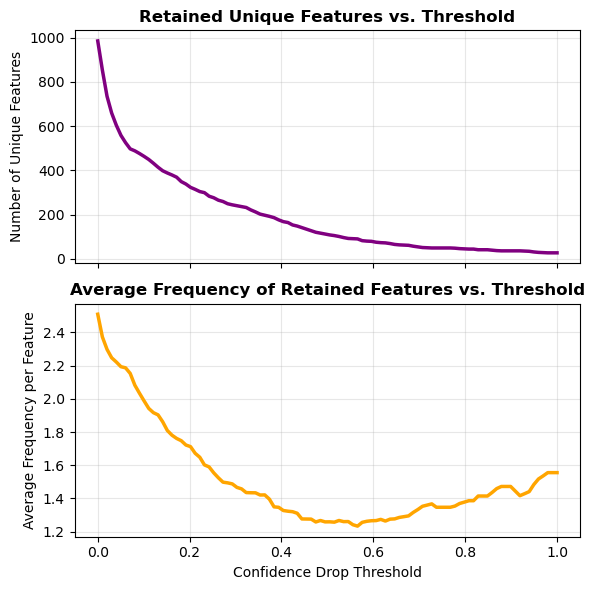

In [8]:
import json 
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

dir_path = "runs_/facial_small_smoothgrad_confidence_drop_0318_1635"
json_files = glob.glob(os.path.join(dir_path, '**', '*.json'), recursive=True)

data_points = []

# 1. 数据读取与基础过滤
for file in json_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
    c = data.get('confidence_drop', 0)
    p = data.get('prediction_target', 0)
    layer = data.get('layer_name', None)
    channel = data.get('channel_id', None)

    if p != 0 and layer is not None and channel is not None:
        ratio = c / p
        if ratio > 0:  # 依然只关注大于 0 的有效比值
            feature_id = f"{layer}_ch{channel}"
            data_points.append({'ratio': ratio, 'id': feature_id})

if data_points:
    # 设定 Threshold 扫描区间 (取到 95 分位数以过滤极端异常值拉长 X 轴)
    ratios = [d['ratio'] for d in data_points]
    max_ratio = 1
    thresholds = np.linspace(0, max_ratio, 100)
    
    unique_counts = []
    avg_frequencies = []
    
    # 2. 遍历每一个 Threshold，计算两个核心指标
    for th in thresholds:
        # 筛选出在当前阈值下存活的数据点
        surviving_points = [d for d in data_points if d['ratio'] >= th]
        
        # 提取当前存活的 Unique Features
        surviving_features = set([d['id'] for d in surviving_points])
        num_unique = len(surviving_features)
        unique_counts.append(num_unique)
        
        # 计算平均出现频率: 当前存活的总激发次数 / 存活的特征种类数
        # 这代表着：“在当前阈值以上，存活下来的特征平均每个触发了多少次？”
        if num_unique > 0:
            avg_freq = len(surviving_points) / num_unique
        else:
            avg_freq = 0
            
        avg_frequencies.append(avg_freq)

    # --- 3. 绘图 ---
    # 创建上下两个子图，共享 X 轴
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
    
    # 图 1: Unique Feature 数量
    ax1.plot(thresholds, unique_counts, color='purple', linewidth=2.5)
    ax1.set_ylabel('Number of Unique Features')
    ax1.set_title('Retained Unique Features vs. Threshold', fontsize=12, weight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 图 2: 平均出现频率
    ax2.plot(thresholds, avg_frequencies, color='orange', linewidth=2.5)
    ax2.set_xlabel('Confidence Drop Threshold')
    ax2.set_ylabel('Average Frequency per Feature')
    ax2.set_title('Average Frequency of Retained Features vs. Threshold', fontsize=12, weight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 优化布局并显示
    plt.tight_layout()
    plt.savefig('data/threshold_analysis.pdf', dpi=300)  # 保存高分辨率图片
    plt.show()

else:
    print("没有找到有效的数据点。")